In [2]:
!pip install -r requirements.txt

In [3]:
import kagglehub
# path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
path = kagglehub.dataset_download("jangedoo/utkface-new")

/home/e20240011884/Documents/M2/Image, sécurité et deep learning/face_filters/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import cv2
import os

In [5]:
# Load face detection classifier
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [6]:
image_size = 128
images = []
ages = []

In [7]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}. Skipping.")
        return []

    grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(
        grey_img, scaleFactor=1.1, minNeighbors=5, minSize=(120, 120)
    )

    crops = []
    for (x, y, w, h) in faces:
        x_max = min(img.shape[1], x + w)
        y_max = min(img.shape[0], y + h)
        x = max(0, x)
        y = max(0, y)

        if w <= 0 or h <= 0:
            continue

        im_cropped = img[y:y_max, x:x_max]
        if im_cropped.size == 0:
            continue

        im_cropped = cv2.cvtColor(im_cropped, cv2.COLOR_BGR2RGB)
        im_cropped = cv2.resize(im_cropped, (image_size, image_size))
        im_cropped = im_cropped.astype("float32") / 255.0
        crops.append(im_cropped)

    return crops

In [8]:
import numpy as np

print("Processing images...")
images = []
ages = []

i = 0
numImg = 15000
for root, dirs, files in os.walk(path):
    for file in files:
        if i >= numImg:
            break
        if file.endswith(".jpg"):
            img_path = os.path.join(root, file)
            processed_crops = preprocess_image(img_path)
            age = int(file.split("_")[0])
            if len(processed_crops) == 0:
                continue
            for crop in processed_crops:
                images.append(crop)
                normalized_age = age / 116
                ages.append(normalized_age)
                i += 1
                if i >= numImg:
                    break

Processing images...


In [9]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/e20240011884/Documents/M2/Image, sécurité et deep learning/face_filters/.venv/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

2025-12-05 09:26:14.318260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 09:26:17.268424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 09:26:28.143078: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, x_train_ages, x_test_ages = train_test_split(
    images, ages, test_size=0.2, random_state=42
)

x_train = np.array(x_train, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)

x_train_ages = np.array(x_train_ages, dtype=np.float32).reshape(-1,1)
x_test_ages = np.array(x_test_ages, dtype=np.float32).reshape(-1,1)

# Crear datasets de tf.data
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train_ages))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((x_test, x_test_ages))
val_dataset = val_dataset.batch(batch_size)

print(x_train.shape, x_train_ages.shape)
print(x_test.shape, x_test_ages.shape)


I0000 00:00:1764923197.486886    5782 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7314 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


(12000, 128, 128, 3) (12000, 1)
(3000, 128, 128, 3) (3000, 1)


In [12]:

from keras.saving import register_keras_serializable

def residual_block(x, filters, strides=1):
    shortcut = x
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding="same")(shortcut)

    x = layers.Conv2D(filters, 3, strides=strides, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def build_encoder(latent_dim):
    image_input = Input(shape=(128,128,3))
    age_input = Input(shape=(1,))

    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(image_input)
    x = residual_block(x, 64, strides=2)  # 32x32
    x = residual_block(x, 128, strides=2) # 16x16
    x = residual_block(x, 256, strides=2) # 8x8

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)

    # Concatenar la edad ANTES del latente
    age_embed = layers.Dense(32, activation="relu")(age_input)
    x = layers.Concatenate()([x, age_embed])

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)

    @register_keras_serializable()
    def sampling(args):
        mean, log_var = args
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5*log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    return Model([image_input, age_input], [z_mean, z_log_var, z], name="encoder")




In [13]:
class FiLM(layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels

    def build(self, input_shape):
        self.gamma_dense = layers.Dense(self.channels)
        self.beta_dense = layers.Dense(self.channels)

    def call(self, inputs):
        x, age = inputs
        gamma = self.gamma_dense(age)[:, None, None, :]
        beta = self.beta_dense(age)[:, None, None, :]
        return x * gamma + beta


def build_decoder(latent_dim):
    z_input = Input(shape=(latent_dim,))
    age_input = Input(shape=(1,))

    # Primer reshape
    x = layers.Dense(8*8*256, activation="relu")(z_input)
    x = layers.Reshape((8,8,256))(x)

    # FiLM 8×8
    x = FiLM(256)([x, age_input])

    # 16x16
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = FiLM(128)([x, age_input])

    # 32x32
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = FiLM(64)([x, age_input])

    # 64x64
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = FiLM(32)([x, age_input])

    # 128x128
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = FiLM(16)([x, age_input])

    output_img = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    return Model([z_input, age_input], output_img, name="decoder")


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from keras_facenet import FaceNet
identity_model = FaceNet().model
identity_model.trainable = False

# --- Preparar modelo VGG para perceptual loss ---
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128,128,3))
vgg.trainable = False
layer_names = ['block3_conv3', 'block4_conv3']
vgg_outputs = [vgg.get_layer(name).output for name in layer_names]
vgg_model = Model(inputs=vgg.input, outputs=vgg_outputs)

def perceptual_loss(x_true, x_pred):
    # VGG espera imágenes en [0,255], actualmente tus imágenes están en [0,1]
    x_true_pp = preprocess_input(x_true * 255.0)
    x_pred_pp = preprocess_input(x_pred * 255.0)
    
    features_true = vgg_model(x_true_pp)
    features_pred = vgg_model(x_pred_pp)
    
    loss = 0
    for f_true, f_pred in zip(features_true, features_pred):
        loss += tf.reduce_mean(tf.square(f_true - f_pred))
    return loss

def identity_loss(x_true, x_pred):
    # FaceNet espera 160x160 y [0,255]
    x_true_resized = tf.image.resize(x_true, (160, 160)) * 255.0
    x_pred_resized = tf.image.resize(x_pred, (160, 160)) * 255.0

    emb_true = identity_model(x_true_resized)
    emb_pred = identity_model(x_pred_resized)

    return tf.reduce_mean(tf.square(emb_true - emb_pred))

def age_loss(y_true_age, y_pred_age):
    return tf.reduce_mean(tf.square(y_true_age - y_pred_age))

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, kl_start=0.0, kl_end=0.01, warmup_steps=10000):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.kl_start = kl_start
        self.kl_end = kl_end
        self.warmup_steps = warmup_steps
        self.step_count = 0

        # Pesos recomendados
        self.recon_weight = 1.0
        self.p_weight = 1e-5
        self.identity_weight = 1000

    def compute_kl_weight(self):
        t = tf.clip_by_value(self.step_count / self.warmup_steps, 0.0, 1.0)
        return self.kl_start + t*(self.kl_end - self.kl_start)

    def train_step(self, data):
        x, age = data
        self.step_count += 1

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder([x, age], training=True)
            reconstruction = self.decoder([z, age], training=True)

            # Reconstruction loss
            mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
            ssim = 1 - tf.image.ssim(x, reconstruction, max_val=1.0)
            recon_loss = tf.reduce_mean(mae + 0.3*ssim)

            # KL Loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            kl_weight = self.compute_kl_weight()

            # Perceptual + Identity (usa tus funciones)
            p_loss = perceptual_loss(x, reconstruction)
            id_loss = identity_loss(x, reconstruction)

            loss = (
                self.recon_weight * recon_loss +
                kl_weight * kl_loss +
                self.p_weight * p_loss +
                self.identity_weight * id_loss
            )

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": loss,
            "recon": recon_loss,
            "kl": kl_loss,
            "kl_w": kl_weight,
            "p_loss": p_loss,
            "id_loss": id_loss
        }

    def test_step(self, data):
        x, age = data
        
        # Forward sin entrenamiento
        z_mean, z_log_var, z = self.encoder([x, age], training=False)
        reconstruction = self.decoder([z, age], training=False)

        # Reconstruction loss
        mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
        ssim = 1 - tf.image.ssim(x, reconstruction, max_val=1.0)
        recon_loss = tf.reduce_mean(mae + 0.3 * ssim)

        # KL
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        # Perceptual + Identity
        p_loss = perceptual_loss(x, reconstruction)
        id_loss = identity_loss(x, reconstruction)

        # OJO: para test NO usamos KL warmup
        kl_weight = self.kl_end  

        total_loss = (
            self.recon_weight * recon_loss +
            kl_weight * kl_loss +
            self.p_weight * p_loss +
            self.identity_weight * id_loss
        )

        return {
            "loss": total_loss,
            "recon": recon_loss,
            "kl": kl_loss,
            "p_loss": p_loss,
            "id_loss": id_loss,
            "kl_w": kl_weight
        }

    def call(self, inputs):
        x, age = inputs
        _, _, z = self.encoder([x, age], training=False)
        reconstruction = self.decoder([z, age], training=False)
        return reconstruction



In [30]:
latent_dim = 128

encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

In [31]:
class SaveEveryN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 20 == 0:
            vae.build((None,) + x_train.shape[1:])
            print(f"\n🔽 Saving VAE on epoch {epoch+1}...")
            vae.encoder.save(f"../Models/Temp/vae_encoder_epoch_{epoch+1}.keras")
            vae.decoder.save(f"../Models/Temp/vae_decoder_epoch_{epoch+1}.keras")
            vae.save_weights(f'../Models/Temp/vae_weights_epoch_{epoch+1}.weights.h5')

In [32]:
# Train
epochs = 30
batch_size = 64

history = vae.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[SaveEveryN()]
)

vae.build((None,) + x_train.shape[1:])


Epoch 1/30


2025-12-05 09:56:03.998753: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-05 09:56:03.998804: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-05 09:56:03.999422: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-05 09:56:03.999516: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert


188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 336ms/step - id_loss: 1.9617e-04 - kl: 4665.1816 - kl_w: 2.0000e-06 - loss: 6.9793 - p_loss: 128903.8984 - recon: 0.3286 - val_id_loss: 2.1687e-04 - val_kl: 5166.4624 - val_kl_w: 0.0100 - val_loss: 59.6011 - val_p_loss: 147926.0156 - val_recon: 0.3233
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 248ms/step - id_loss: 2.0581e-04 - kl: 3772.2400 - kl_w: 2.0000e-06 - loss: 7.1109 - p_loss: 131473.6875 - recon: 0.3238 - val_id_loss: 1.7746e-04 - val_kl: 4671.2280 - val_kl_w: 0.0100 - val_loss: 54.0846 - val_p_loss: 137732.1250 - val_recon: 0.3082
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 250ms/step - id_loss: 1.8992e-04 - kl: 2454.5215 - kl_w: 2.0000e-06 - loss: 6.2929 - p_loss: 116008.3359 - recon: 0.2976 - val_id_loss: 1.9507e-04 - val_kl: 3075.5906 - val_kl_w: 0.0100 - val_loss: 37.9531 - val_p_loss: 133986.2812 - val_recon: 0.3028
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - id_loss: 1.6387e-04 - kl: 3912.9087 - kl_w: 2.0000e-06 - loss: 7.0

In [33]:
vae.encoder.save( "../Models/vae_encoder.keras")
vae.decoder.save( "../Models/vae_decoder.keras")

vae.save_weights('../Models/vae_weights.weights.h5')

In [34]:
# encoder = build_encoder(latent_dim)
# decoder = build_decoder(latent_dim)

# vae = VAE(encoder, decoder)

# vae.build((None,) + x_train.shape[1:])
# vae.load_weights("../Models/Temp/vae_weights_epoch_40.weights.h5")

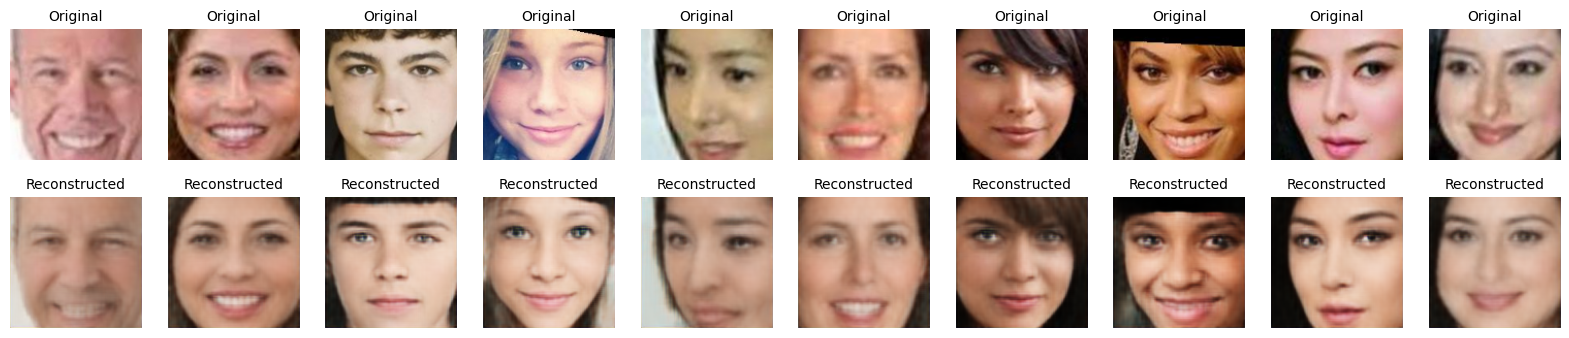

In [35]:
import matplotlib.pyplot as plt

n = 10  # Número de imágenes a mostrar

# Tomar las primeras n imágenes y edades
x_sample = tf.convert_to_tensor(x_test[:n], dtype=tf.float32)
age_sample = tf.convert_to_tensor(x_test_ages[:n], dtype=tf.float32)

# Obtener las representaciones latentes y los skips
z_mean, z_log_var, z = vae.encoder([x_sample, age_sample], training=False)

# Decodificar las imágenes
decoded_imgs = vae.decoder([z, age_sample], training=False)

# Configuración de la figura
plt.figure(figsize=(20, 4))

for i in range(n):
    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_sample[i].numpy())
    plt.axis("off")
    plt.title("Original", fontsize=10)

    # Imagen reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].numpy())
    plt.axis("off")
    plt.title("Reconstructed", fontsize=10)

plt.show()


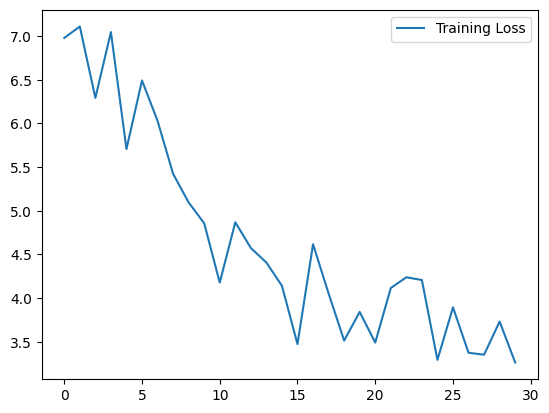

In [36]:
loss = history.history['loss']

epoch_range = range(epochs)

plt.plot(epoch_range, loss, label='Training Loss')
plt.legend()
plt.show()

In [37]:
def generate_age_variations(img_path, ages=[5, 15, 25, 40, 60, 80]):
    """
    Genera múltiples versiones de una imagen con diferentes edades.
    Requiere:
        - vae: modelo entrenado
        - preprocess_image: debe devolver recortes faciales normalizados [0,1]
    """

    # --- Preprocesamiento ---
    face_crops = preprocess_image(img_path)
    if len(face_crops) == 0:
        raise ValueError("No se detectó ninguna cara en la imagen.")

    face = face_crops[0]

    # Batch de tamaño 1
    face_batch = np.expand_dims(face, axis=0)
    face_tensor = tf.convert_to_tensor(face_batch, dtype=tf.float32)

    decoded_results = []

    # --- Procesar cada edad ---
    for age_value in ages:
        age_tensor = tf.convert_to_tensor([[age_value]], dtype=tf.float32)

        # Encode + obtener skips
        enc_out = vae.encoder([face_tensor, age_tensor], training=False)
        z_mean, z_log_var, z = enc_out[:3]

        # Decode con skips
        decoded_img = vae.decoder([z, age_tensor], training=False)

        decoded_results.append(decoded_img[0].numpy())

    # --- Mostrar ---
    plt.figure(figsize=(3 * len(ages), 4))

    # Mostrar imagen original
    plt.subplot(1, len(ages) + 1, 1)
    plt.imshow(face)
    plt.title("Original")
    plt.axis("off")

    # Mostrar variaciones
    for i, age_value in enumerate(ages):
        plt.subplot(1, len(ages) + 1, i + 2)
        plt.imshow(decoded_results[i])
        plt.title(f"Edad: {age_value}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return decoded_results

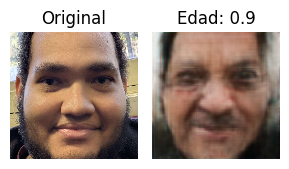

[array([[[0.8457245 , 0.8902183 , 0.751802  ],
         [0.9103491 , 0.94329244, 0.8659126 ],
         [0.9180628 , 0.9565987 , 0.87560064],
         ...,
         [0.7557103 , 0.7843108 , 0.64771247],
         [0.79209197, 0.77266705, 0.69504166],
         [0.68991363, 0.673318  , 0.61791897]],
 
        [[0.8901173 , 0.9049551 , 0.8226314 ],
         [0.9384717 , 0.9293627 , 0.93375295],
         [0.9333716 , 0.92968386, 0.9260303 ],
         ...,
         [0.71546847, 0.68060064, 0.63785875],
         [0.6854946 , 0.64049673, 0.6550193 ],
         [0.69395643, 0.6159261 , 0.6341439 ]],
 
        [[0.92939484, 0.93110543, 0.8479443 ],
         [0.9360547 , 0.92932653, 0.93609464],
         [0.92091537, 0.9198146 , 0.91092914],
         ...,
         [0.760909  , 0.693474  , 0.66567695],
         [0.70966995, 0.6495482 , 0.68886745],
         [0.7484081 , 0.71653324, 0.69723946]],
 
        ...,
 
        [[0.10502717, 0.16995643, 0.18993203],
         [0.14456022, 0.14302172, 0.11305

In [58]:
generate_age_variations(
    img_path="../Images/MK.jpg",
    # ages=[0, -5, -2 ,-1, 1, 2, 5]
    ages=[0.9]
)